# XMEAS10 · 论文结果图作图台 (operator-augmented, VetoGate)

生成 **Fig. 4 / 5 / 6 / 7**（论文 `paper/manuscript.docx` 的四张定量结果图）：

| Fig | 内容 | 文件 |
|-----|------|------|
| **4** | prognostic **recall** vs 数据比例 ρ（log） | `fig4_recall_vs_rho.png/pdf` |
| **5** | (a) **FAR** (b) **lead time** vs ρ（含 FAR≤0.05 预算阴影） | `fig5_far_lead_vs_rho.png/pdf` |
| **6** | **recall–FAR** 散点（每算子每 ρ 一个点）+ Pareto 前沿 + FAR=0.05 线 | `fig6_recall_far_pareto.png/pdf` |
| **7** | horizon-mean **MSE ×10³** vs ρ（log），collapsed baselines 平带 | `fig7_mse_vs_rho.png/pdf` |

**数据源**：baseline 曲线使用 `fullsweep` 的 Run 9–10 clean 指标；VetoGate 使用 3 个 gate seeds 的均值（100% 档沿用已保存 gate），并由 `scripts/reproduce_paper_metrics.py` 按论文口径重新计算。Lead time 只对实际提前预警的 onsets 取均值，forecast-origin 预警计为 3 min。
方法集与图注一致：算子池 raw/∇(diff)/∇²/**VetoGate** + 两个 zero-shot(Time-MoE/Sundial) + 两个最强监督基线(STA-ConvBiLSTM/TCN-Transformer)；Fig 6 只画四个算子。
**不改** `plot_gate.ipynb`（旧 gate 作图台）。

In [21]:
# === 配置 + 数据（Table 1/2/3/5；论文口径的 VetoGate 结果）===
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import patheffects as pe
import scienceplots  # noqa: F401  (registers the 'science'/'nature' styles)

HERE = Path("/home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10")

# 数据比例 rho（论文 6 档），x 轴 log
RHO_PCT = np.array([1, 5, 10, 25, 50, 100], dtype=float)
RHO_LAB = ["1%", "5%", "10%", "25%", "50%", "100%"]

# ---- Table 1: recall ----
RECALL = {
    # VetoGate：3 个 gate seeds 的均值（100% 使用已保存的 r1p0 gate）。
    # 所有指标均按 scripts/reproduce_paper_metrics.py 的论文口径计算。
    "vetogate": [0.677, 0.670, 0.703, 0.693, 0.713, 0.743],
    "diff2": [0.579, 0.684, 0.711, 0.711, 0.737, 0.737],
    "diff":  [0.605, 0.579, 0.684, 0.711, 0.684, 0.737],
    "raw":   [0.289, 0.395, 0.526, 0.447, 0.553, 0.632],
    "time_moe": [0.263]*6,
    "sundial":  [0.211]*6,
    "sta":   [0.000, 0.263, 0.289, 0.447, 0.553, 0.605],
    "tcn":   [0.026, 0.053, 0.132, 0.474, 0.368, 0.368],
}
# ---- Table 2: FAR ----
FAR = {
    "diff":  [0.021, 0.022, 0.016, 0.013, 0.005, 0.008],
    "raw":   [0.002, 0.005, 0.006, 0.007, 0.009, 0.010],
    "diff2": [0.154, 0.121, 0.099, 0.077, 0.070, 0.071],
    "vetogate": [0.064, 0.043, 0.036, 0.029, 0.024, 0.033],
    "time_moe": [0.002]*6,
    "sundial":  [0.001]*6,
    "sta":   [0.001, 0.032, 0.030, 0.008, 0.011, 0.010],
    "tcn":   [0.002, 0.000, 0.009, 0.008, 0.009, 0.023],
}
# ---- Table 3: lead time (min) ----
LEAD = {
    # Mean over anticipated onsets only; forecast-origin warning is 3 min.
    "vetogate": [10.14, 9.32, 9.75, 9.67, 10.00, 10.07],
    "diff2": [1.31, 1.35, 1.35, 1.40, 1.35, 1.35],
    "diff":  [1.16, 1.16, 1.35, 1.31, 1.16, 1.31],
    "raw":   [0.63, 0.77, 0.92, 0.82, 0.92, 1.06],
    "time_moe": [0.39]*6,
    "sundial":  [0.34]*6,
    "sta":   [0.00, 0.58, 0.44, 0.82, 0.97, 1.16],
    "tcn":   [0.05, 0.05, 0.19, 0.82, 0.68, 0.73],
}
# ---- Table 5: MSE x10^3 ----
MSE = {
    "diff":  [0.087, 0.075, 0.064, 0.054, 0.051, 0.048],
    "vetogate": [0.122, 0.097, 0.083, 0.068, 0.062, 0.057],
    "diff2": [0.159, 0.119, 0.100, 0.082, 0.071, 0.065],
    "raw":   [0.237, 0.131, 0.103, 0.093, 0.073, 0.064],
    "time_moe": [0.115]*6,
    "sundial":  [0.137]*6,
    "sta":   [0.423, 0.320, 0.263, 0.074, 0.073, 0.063],
    "tcn":   [0.405, 0.276, 0.186, 0.119, 0.129, 0.130],
}
# collapsed DL trio (MSE, flat ~0.42) -> Fig 7 band
MSE_COLLAPSED = {
    "DiPCA-LSTM": [0.424, 0.424, 0.425, 0.426, 0.429, 0.427],
    "CNN-LSTM":   [0.423, 0.423, 0.423, 0.423, 0.424, 0.424],
    "LSTM-GRU":   [0.424, 0.423, 0.424, 0.424, 0.424, 0.425],
}

# ---- 配色：三层视觉等级，把 VetoGate 顶到最前 ----
# 1) VetoGate = 唯一的饱和深蓝 + 最粗线 + 实心星 + 白色描边（穿过别的线时不糊）
# 2) 其余算子（raw / ∇ / ∇²）= 有彩色但压低饱和度，细线 + 空心 marker
# 3) baseline = 一律去彩色，只用灰阶；用线型分两族：
#       零样本基础模型 -> 暖灰 + 长虚线
#       有监督深度模型 -> 冷灰 + 点线
IKB="#002FA7"; INK="#0a0a0a"; GREY_DARK="#5c5c5c"; GREY_MID="#8f8f8d"
GREY_LIGHT="#c4c4c2"; PAPER="#ffffff"
WARM_GREY="#8a8172"; WARM_GREY_L="#a89f8c"     # 零样本 TSFM
COOL_GREY="#78868f"; COOL_GREY_L="#9aa6ad"     # 有监督 DL
STYLE = {   # key -> (color, marker, linestyle, lw, label)
    "raw":   ("#4f8f7b", "s", "-",            1.6, "Timer-XL raw"),
    "diff":  ("#cf6a2e", "o", "-",            1.8, r"Timer-XL $\nabla$ (diff)"),
    "diff2": ("#7048b0", "^", "-",            1.8, r"Timer-XL $\nabla^{2}$"),
    "vetogate": (IKB,       "*", "-",            2.8, "VetoGate"),
    "time_moe": (WARM_GREY,   None, (0,(6,2.2)),   1.5, "Time-MoE (zero-shot)"),
    "sundial":  (WARM_GREY_L, None, (0,(2.4,1.8)), 1.5, "Sundial (zero-shot)"),
    "sta":   (COOL_GREY,   "x", (0,(1,1.4)),  1.3, "STA-ConvBiLSTM"),
    "tcn":   (COOL_GREY_L, "+", (0,(1,1.4)),  1.3, "TCN-Transformer"),
}
OPS      = ["raw", "diff", "diff2", "vetogate"]  # 算子池 + VetoGate 决策
ZEROSHOT = ["time_moe", "sundial"]
BASE2    = ["sta", "tcn"]                          # 两个最强监督基线
FIG4SET  = OPS + ZEROSHOT + BASE2                  # Fig 4/5/7 方法集

# ---- 出图尺寸 / 字号：以 Fig. 3 为基准，所有图统一 ----
# 正文宽 14.5 cm（A4，边距 4.0/2.5）。所有图统一导出 20 cm 宽，插入 Word 后
# 一律缩放 0.72x，字号在纸面上才完全一致。
FIG_W_CM = 20.0
cm = lambda v: v / 2.54
FS = dict(tick=9, label=10.5, title=8.6, legend=7.6, annot=9.5, note=8.6)

# SciencePlots 的学术底子：刻度朝内、四边刻度、副刻度、细轴线。
#   science  -> 基础学术样式（但默认 serif + LaTeX）
#   no-latex -> 关掉 text.usetex，本机不依赖 LaTeX
#   nature   -> 把字族拉回 sans-serif
# 之后再用我们自己的 rcParams 覆盖字体和留白，顺序不能反。
plt.style.use(["science", "no-latex", "nature"])

# 全图统一 Arial（含数学符号）。mathtext 默认走 DejaVu Sans，必须显式改成 custom，
# 否则 rho / nabla / tau / x10^3 这些会和正文不是同一套字。Arial 缺的字形
# （nabla、ell 等）由 stixsans 补齐——同样是无衬线，接得上。
# 数学斜体不能用 Arial Italic：它的希腊 tau (U+03C4) 是平顶横杠 + 笔直竖干、
# 底部无卷尾的字形，小字号下和斜体拉丁 T 几乎分不开（Fig. 3 的 tau* 会被读成 T*）。
# 换成与 Arial 度量兼容的 Liberation Sans Italic：拉丁字形基本不变，tau/rho 才正常。
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Liberation Sans:italic",
    "mathtext.bf": "Arial:bold",
    "mathtext.fallback": "stixsans",
    "axes.linewidth": 0.6, "svg.fonttype": "none",
    "pdf.fonttype": 42, "ps.fonttype": 42,   # 嵌入 TrueType，PDF 里保持可编辑文本
    "savefig.pad_inches": 0.10,              # science 改成 0.05，改回来保持导出尺寸
    "xtick.minor.visible": True, "ytick.minor.visible": True,
})

def _base_ax(ax):
    """学术版坐标框：黑色细边框、刻度朝内、四边都有刻度、极淡网格。"""
    ax.set_facecolor(PAPER)
    ax.grid(color=GREY_LIGHT, lw=0.45, alpha=0.40, zorder=0)
    for s in ax.spines.values(): s.set_color(INK); s.set_linewidth(0.6)
    ax.tick_params(which="major", direction="in", top=True, right=True,
                   length=3.2, width=0.6, colors=INK, labelsize=FS["tick"])
    ax.tick_params(which="minor", direction="in", top=True, right=True,
                   length=1.7, width=0.5, colors=INK)

def _plot_curve(ax, key, ydict, big_marker=False):
    c, mk, ls, lw, lab = STYLE[key]
    y = ydict[key]
    is_op = key in OPS
    hero = key == "vetogate"
    if hero:   # 白色描边垫底，保证与其它曲线交叉处仍然清晰
        ax.plot(RHO_PCT, y, color=PAPER, ls=ls, lw=lw + 1.8, zorder=11,
                solid_capstyle="round", clip_on=True)
    ax.plot(RHO_PCT, y, color=c, ls=ls, lw=lw, marker=mk,
            ms=(10.5 if hero else 5.2) if is_op else 4.6,
            mfc=(c if hero else PAPER) if is_op else c,
            mec=c, mew=(0.8 if hero else 1.2) if is_op else 1.0,
            zorder=(12 if hero else 6) if is_op else 4,
            label=lab, clip_on=True,
            # VetoGate 加白色描边，压过所有交叉线
            path_effects=[pe.Stroke(linewidth=lw + 1.8, foreground=PAPER), pe.Normal()]
                         if hero else None)

def _finish_x(ax):
    ax.set_xscale("log")
    ax.set_xticks(RHO_PCT); ax.set_xticklabels(RHO_LAB)
    ax.set_xlim(0.85, 118)
    ax.set_xlabel(r"training-subset ratio  $\rho$   (log scale)", fontsize=FS["label"], color=INK)

def _save(fig, stem):
    # Vector masters plus 600-dpi raster preview/submission export.
    fig.savefig(HERE / f"{stem}.svg", facecolor=PAPER, bbox_inches="tight")
    fig.savefig(HERE / f"{stem}.pdf", facecolor=PAPER, bbox_inches="tight")
    for ext in ("png", "tiff"):
        fig.savefig(HERE / f"{stem}.{ext}", dpi=600, facecolor=PAPER, bbox_inches="tight")
    print("saved:", HERE / f"{stem}.png", "+ .svg/.pdf/.tiff")

print("cell1 ok · methods:", FIG4SET)


cell1 ok · methods: ['raw', 'diff', 'diff2', 'vetogate', 'time_moe', 'sundial', 'sta', 'tcn']


## Fig. 3 — 两个示例窗口（从 H=5 算子预测数组，非表格）

held-out 测试集上两个 ante-onset 窗口，展示 (ℓ, u) 带、真值、以及 ∇/∇²/Union 预测。
窗口号由下一格的 `FIG3_WIN` 单点定义（全局窗口序号 gi，run 9 占 gi 0–1808，run 10 占 1809+）：
- **(a) gi 1604**（Run 9, 84.95 h）：稳定爬坡，**∇(diff) 与 ∇² 都越过 u → 抓到**。
- **(b) gi 3563**（Run 10, 92.45 h）：曲线加速上冲，**∇ 平在带内漏掉；∇² 加速穿过 u → 抓到**。

> ⚠️ 待办（内容问题，未改）：(a) 面板标题写的 "every baseline misses" 与数据不符——
> Timer-XL-raw 在 t=15 min 达 0.2417 > u=0.24147，同样越限。全测试集里"∇ 和 ∇² 都抓到
> 且 8 个 baseline 全 miss"的干净窗口只有 gi 1116 / 1117（Run 9, 60.55 / 60.60 h）。
> (b) 的标题成立，无需改动。

**Union 用方向感知包络表示**（up-onset = max(∇,∇²)，down = min），阴影带 = [min,max]，蓝星 = union 首次越限点。
数据源 = `results/forecast_...diff_train25p5...`（∇）与 `results/op_diff2_p5_test`（∇²），mag25 限 `setting/limits_tep_xmeas10_mag25.csv`。

saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/testset_purge_rate.png + .svg/.pdf/.tiff


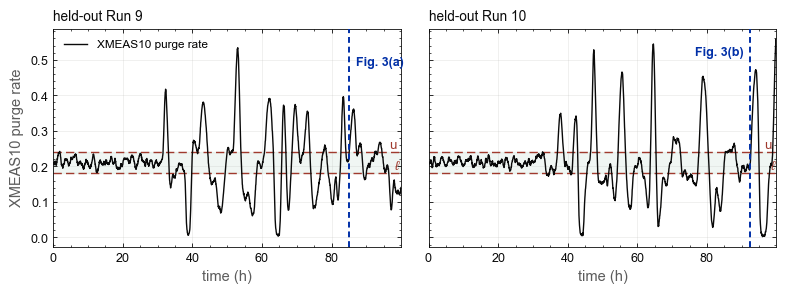

In [21]:
# --- Fig. 3 example windows :: SINGLE SOURCE OF TRUTH (global window indices gi) ---
# Both the test-set overview cell and Fig. 3 read from here -> they can never drift.
# (a)=steady-ramp onset (grad & grad2 catch, all baselines miss); (b)=curving onset (only grad2).
FIG3_WIN = {"a": 1604, "b": 3563}

# === Test-set overview — XMEAS10 purge rate on the held-out runs (Run 9, Run 10, mag25) ===
# Full measured trajectories that Fig. 3's example windows are drawn from. Same (ell, u)
# band as Fig. 3; each dashed IKB line marks an example window's forecast origin (t=0),
# computed from the SAME global window index gi as Fig. 3's PANELS -> exact correspondence.
import pandas as pd
_LOW = Path("/home/aicode/sherwin/dataset/TEP/csv_5var_lowmag")
_TGT = "XMEAS10 Purge Rate"; _STEP_MIN = 3.0; _SEQ = 96
def _series(run):
    return pd.read_csv(sorted(_LOW.glob(f"*IDV13*_25_Run{run}.csv"))[0])[_TGT].to_numpy(float)
_lim = pd.read_csv(Path("/home/aicode/sherwin/TSFM/setting/limits_tep_xmeas10_mag25.csv"), index_col=0)
_ELL, _U = float(_lim.loc[_TGT].iloc[2]), float(_lim.loc[_TGT].iloc[1])

# --- Fig. 3 example windows: keep these global indices identical to Fig. 3's PANELS ---
_GI = list(FIG3_WIN.items())          # single source of truth (cell 1)
_WPR = len(_series(9)) - _SEQ - _SEQ + 1                      # windows per run
def _origin(gi):                                             # -> (run, origin sample index)
    run, local = (9, gi) if gi < _WPR else (10, gi - _WPR)
    return run, _SEQ + local - 1                             # t=0 = ctx[-1] = s[st-1], as in Fig. 3
_MARKS = {}
for tag, gi in _GI:
    r, so = _origin(gi); _MARKS.setdefault(r, []).append((so, tag))

fig, axes = plt.subplots(1, 2, figsize=(20/2.54, 7.5/2.54), sharey=True)
fig.patch.set_facecolor(PAPER)
for ax, run in zip(axes, (9, 10)):
    _base_ax(ax)
    s = _series(run); t = np.arange(len(s)) * _STEP_MIN / 60.0            # hours
    ax.axhspan(_ELL, _U, color="#2e8b57", alpha=0.07, zorder=0)
    for yv, nm in ((_U, "u"), (_ELL, r"$\ell$")):
        ax.axhline(yv, color="#a03a2e", lw=1.0, ls=(0, (6, 3)), zorder=2)
        ax.text(t[-1], yv, f"{nm} ", color="#a03a2e", fontsize=9.5, va="bottom", ha="right")
    ax.plot(t, s, color=INK, lw=1.0, zorder=4,
            label=("XMEAS10 purge rate" if run == 9 else None))
    for so, tag in _MARKS.get(run, []):
        to = t[so]
        ax.axvline(to, color=IKB, lw=1.4, ls=(0, (3, 2)), zorder=5)
        # 靠近右边框时把标签翻到竖线左侧，否则文字被 axes 切掉（Run 10 的 Fig. 3(b)）
        _rt = to > t[0] + 0.85 * (t[-1] - t[0])
        ax.annotate(f"Fig. 3({tag})", (to, ax.get_ylim()[1]), textcoords="offset points",
                    xytext=(-5 if _rt else 5, -13), fontsize=9, color=IKB,
                    fontweight="bold", va="top", ha="right" if _rt else "left")
    ax.set_xlabel("time (h)", fontsize=10.5, color=GREY_DARK)
    ax.set_title(f"held-out Run {run}", fontsize=9.8, color=INK, loc="left", pad=6)
    ax.set_xlim(t[0], t[-1])
axes[0].set_ylabel("XMEAS10 purge rate", fontsize=10.5, color=GREY_DARK)
axes[0].legend(fontsize=8.5, loc="upper left", framealpha=0.92, edgecolor=GREY_LIGHT)
fig.tight_layout(); _save(fig, "testset_purge_rate"); plt.show()

saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/fig3_examples.png + .svg/.pdf/.tiff


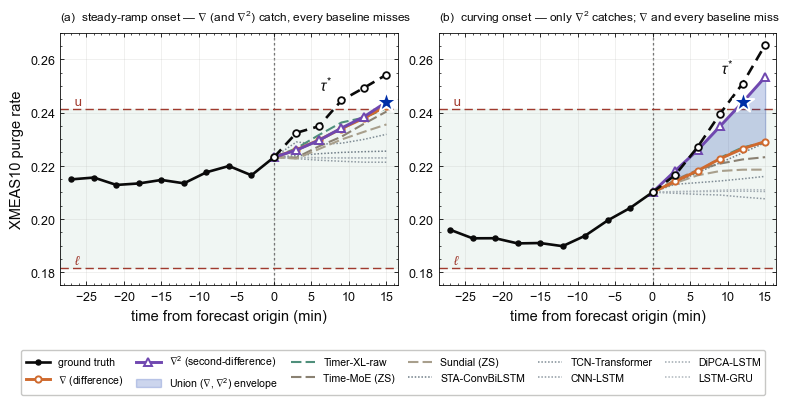

In [22]:
# === Fig. 3 — two example ante-onset windows: operators vs ALL baselines (H=5, r1p0) ===
# Data dirs = 100%-data (r1p0) block of setting/bm_fullsweep.yaml; mag25 limits, eval_steps=5.
# DL baselines are the diff-input, mag25-trained (train25) variants (the paper set), restored
# to the raw purge-rate domain (pred.npy). All method arrays share the 3618-window test order.
import pandas as pd
RES        = Path("/home/aicode/sherwin/TSFM/results")
LOWMAG_DIR = Path("/home/aicode/sherwin/dataset/TEP/csv_5var_lowmag")
TSFM_ROOT  = Path("/home/aicode/sherwin/TSFM")
SEQ_LEN = PRED_LEN = 96; H5 = 5; TGT = "XMEAS10 Purge Rate"
_BSUF = "timer_xl_MultivariateDatasetYAMLSplitFewShot_sl96_it96_ot96_lr5e-06_bt32_wd0_el8_dm1024_dff2048_nh8_cosTrue_test_0"
def _dl(m, dm, dff, el):
    return (f"long_term_forecast_TEP_IDV13_XMEAS10_5var_diff_{m}_train25_r1p0_{m}"
            f"_MultivariateDatasetYAMLSplitFewShot_sl96_it96_ot96_lr0.001_bt128_wd0"
            f"_el{el}_dm{dm}_dff{dff}_nh8_cosTrue_{m}-X10-diff_0")
DIRS = {
    "diff":  f"forecast_TEP_IDV13_XMEAS10_5var_diff_train25p5_few_r1p0_{_BSUF}",
    "diff2": "op_diff2_p5_test",
    "raw":   f"forecast_TEP_IDV13_XMEAS10_5var_raw_train25p5_few_r1p0_{_BSUF}",
    "time_moe": "fm_time_moe_xmeas10_mag25_test",
    "sundial":  "fm_sundial_xmeas10_mag25_test",
    "cnnlstm":  _dl("CNNLSTM", 230, 1408, 2),
    "dipca":    _dl("DiPCALSTM", 472, 2048, 2),
    "lstmgru":  _dl("LSTMGRU", 316, 2048, 1),
    "sta":      _dl("STAConvBiLSTM", 268, 2048, 1),
    "tcn":      _dl("TCNTransformer", 128, 512, 2),
}
def _csv(run):
    return pd.read_csv(sorted(LOWMAG_DIR.glob(f"*IDV13*_25_Run{run}.csv"))[0])[TGT].to_numpy(float)
def _limits():
    df = pd.read_csv(TSFM_ROOT / "setting/limits_tep_xmeas10_mag25.csv", index_col=0)
    return float(df.loc[TGT].iloc[2]), float(df.loc[TGT].iloc[1])           # (ell, u)
def _p5(d):
    p = np.load(RES / d / "pred.npy"); return (p[:, :, 0] if p.ndim == 3 else p)[:, :H5].astype(float)

ELL, U = _limits()
F = {k: _p5(v) for k, v in DIRS.items()}
WPR = len(_csv(9)) - SEQ_LEN - PRED_LEN + 1
_loc = lambda gi: (9, gi) if gi < WPR else (10, gi - WPR)

# ---- visual tiers -------------------------------------------------------
C_D, C_D2 = STYLE["diff"][0], STYLE["diff2"][0]
TSFM_STY = {   # foundation-model baselines: dashed, coloured, thin
    "raw":      ("Timer-XL-raw",  STYLE["raw"][0],      (0, (5, 2)), 1.5),
    "time_moe": ("Time-MoE (ZS)", STYLE["time_moe"][0], (0, (5, 2)), 1.5),
    "sundial":  ("Sundial (ZS)",  STYLE["sundial"][0],  (0, (5, 2)), 1.5),
}
DL_STY = {     # supervised DL baselines: dotted, cool grey, thinnest
    "sta":     ("STA-ConvBiLSTM",  "#6f7d87", (0, (1, 1.2)), 1.1),
    "tcn":     ("TCN-Transformer", "#7f8c95", (0, (1, 1.2)), 1.1),
    "cnnlstm": ("CNN-LSTM",        "#8f9aa2", (0, (1, 1.2)), 1.1),
    "dipca":   ("DiPCA-LSTM",      "#9fa9b0", (0, (1, 1.2)), 1.1),
    "lstmgru": ("LSTM-GRU",        "#afb7bd", (0, (1, 1.2)), 1.1),
}
PANELS = [("a", FIG3_WIN["a"], r"steady-ramp onset — $\nabla$ (and $\nabla^{2}$) catch, every baseline misses"),
          ("b", FIG3_WIN["b"], r"curving onset — only $\nabla^{2}$ catches; $\nabla$ and every baseline miss")]
CTX = 10
fig, axes = plt.subplots(1, 2, figsize=(20/2.54, 10/2.54)); fig.patch.set_facecolor(PAPER)
H = {}   # label -> handle (for one shared legend)
for ax, (tag, gi, note) in zip(axes, PANELS):
    _base_ax(ax)
    run, local = _loc(gi); s = _csv(run); st = SEQ_LEN + local
    ctx = s[st-CTX:st]; fut = s[st:st+H5]
    tctx = (np.arange(-CTX, 0) + 1) * 3.0; tf = np.arange(1, H5+1) * 3.0
    x = np.r_[0, tf]
    diff, dff2 = F["diff"][gi], F["diff2"][gi]
    up = (fut > U).any()
    edge = np.maximum(diff, dff2) if up else np.minimum(diff, dff2)          # union active edge
    # (ell,u) band
    ax.axhspan(ELL, U, color="#2e8b57", alpha=0.07, zorder=0)
    for yv, nm in ((U, "u"), (ELL, r"$\ell$")):
        ax.axhline(yv, color="#a03a2e", lw=1.0, ls=(0, (6, 3)), zorder=2)
        ax.text(tctx[0], yv, f" {nm}", color="#a03a2e", fontsize=9.5, va="bottom", ha="left")
    ax.axvline(0, color=GREY_DARK, lw=0.9, ls=(0, (2, 2)), zorder=1)
    # DL baselines (bottom tier)
    for k, (lbl, col, ls, lw) in DL_STY.items():
        h, = ax.plot(x, np.r_[ctx[-1], F[k][gi]], color=col, ls=ls, lw=lw, zorder=3)
        H.setdefault(lbl, h)
    # TSFM baselines (mid tier)
    for k, (lbl, col, ls, lw) in TSFM_STY.items():
        h, = ax.plot(x, np.r_[ctx[-1], F[k][gi]], color=col, ls=ls, lw=lw, zorder=4)
        H.setdefault(lbl, h)
    # Union envelope (operator)
    hU = ax.fill_between(tf, np.minimum(diff, dff2), np.maximum(diff, dff2),
                         color=IKB, alpha=0.20, zorder=2)
    H.setdefault(r"Union ($\nabla,\nabla^{2}$) envelope", hU)
    # operators (hero)
    hd, = ax.plot(x, np.r_[ctx[-1], diff], color=C_D, lw=2.1, marker="o", ms=4.5,
                  mfc=PAPER, mew=1.4, zorder=6); H.setdefault(r"$\nabla$ (difference)", hd)
    h2, = ax.plot(x, np.r_[ctx[-1], dff2], color=C_D2, lw=2.1, marker="^", ms=5.6,
                  mfc=PAPER, mew=1.4, zorder=6); H.setdefault(r"$\nabla^{2}$ (second-difference)", h2)
    # ground truth (top)
    hg, = ax.plot(tctx, ctx, color=INK, lw=1.9, marker="o", ms=3.6, zorder=7)
    ax.plot(x, np.r_[ctx[-1], fut], color=INK, lw=1.9, ls=(0, (4, 2.4)),
            marker="o", ms=4.8, mfc=PAPER, mew=1.3, zorder=7)
    H.setdefault("ground truth", hg)
    # union first crossing star
    cu = np.where((edge > U) | (edge < ELL))[0]
    if len(cu):
        ax.scatter(tf[cu[0]], edge[cu[0]], s=260, marker="*", c=IKB,
                   edgecolor="white", linewidth=1.4, zorder=12)
    # true first crossing tau* — 放到真值点的左上方并加白色描边、置于最上层，
    # 否则在 (b) 这种陡坡面板里会被 zorder=7 的黑色真值虚线糊掉。
    ctr = np.where((fut > U) | (fut < ELL))[0]
    if len(ctr):
        ax.annotate(r"$\tau^{*}$", (tf[ctr[0]], fut[ctr[0]]), textcoords="offset points",
                    xytext=(-15, 7), fontsize=11, color=INK, zorder=13,
                    path_effects=[pe.Stroke(linewidth=2.6, foreground=PAPER), pe.Normal()])
    ax.set_ylim(0.175, 0.27)
    ax.set_xlim(tctx[0] - 1.5, tf[-1] + 1.5)
    ax.set_xlabel("time from forecast origin (min)", fontsize=FS["label"], color=INK)
    ax.set_title(f"({tag})  {note}", fontsize=8.6, color=INK, loc="left", pad=8)
axes[0].set_ylabel("XMEAS10 purge rate", fontsize=FS["label"], color=INK)
order = ["ground truth", r"$\nabla$ (difference)", r"$\nabla^{2}$ (second-difference)",
         r"Union ($\nabla,\nabla^{2}$) envelope",
         "Timer-XL-raw", "Time-MoE (ZS)", "Sundial (ZS)",
         "STA-ConvBiLSTM", "TCN-Transformer", "CNN-LSTM", "DiPCA-LSTM", "LSTM-GRU"]
fig.legend([H[k] for k in order], order, loc="lower center", ncol=6, fontsize=7.6,
           frameon=True, framealpha=0.95, facecolor=PAPER, edgecolor=GREY_LIGHT, columnspacing=1.2, handlelength=2.3,
           bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.15, 1, 1))
_save(fig, "fig3_examples"); plt.show()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/fig4_recall_vs_rho.png + .svg/.pdf/.tiff


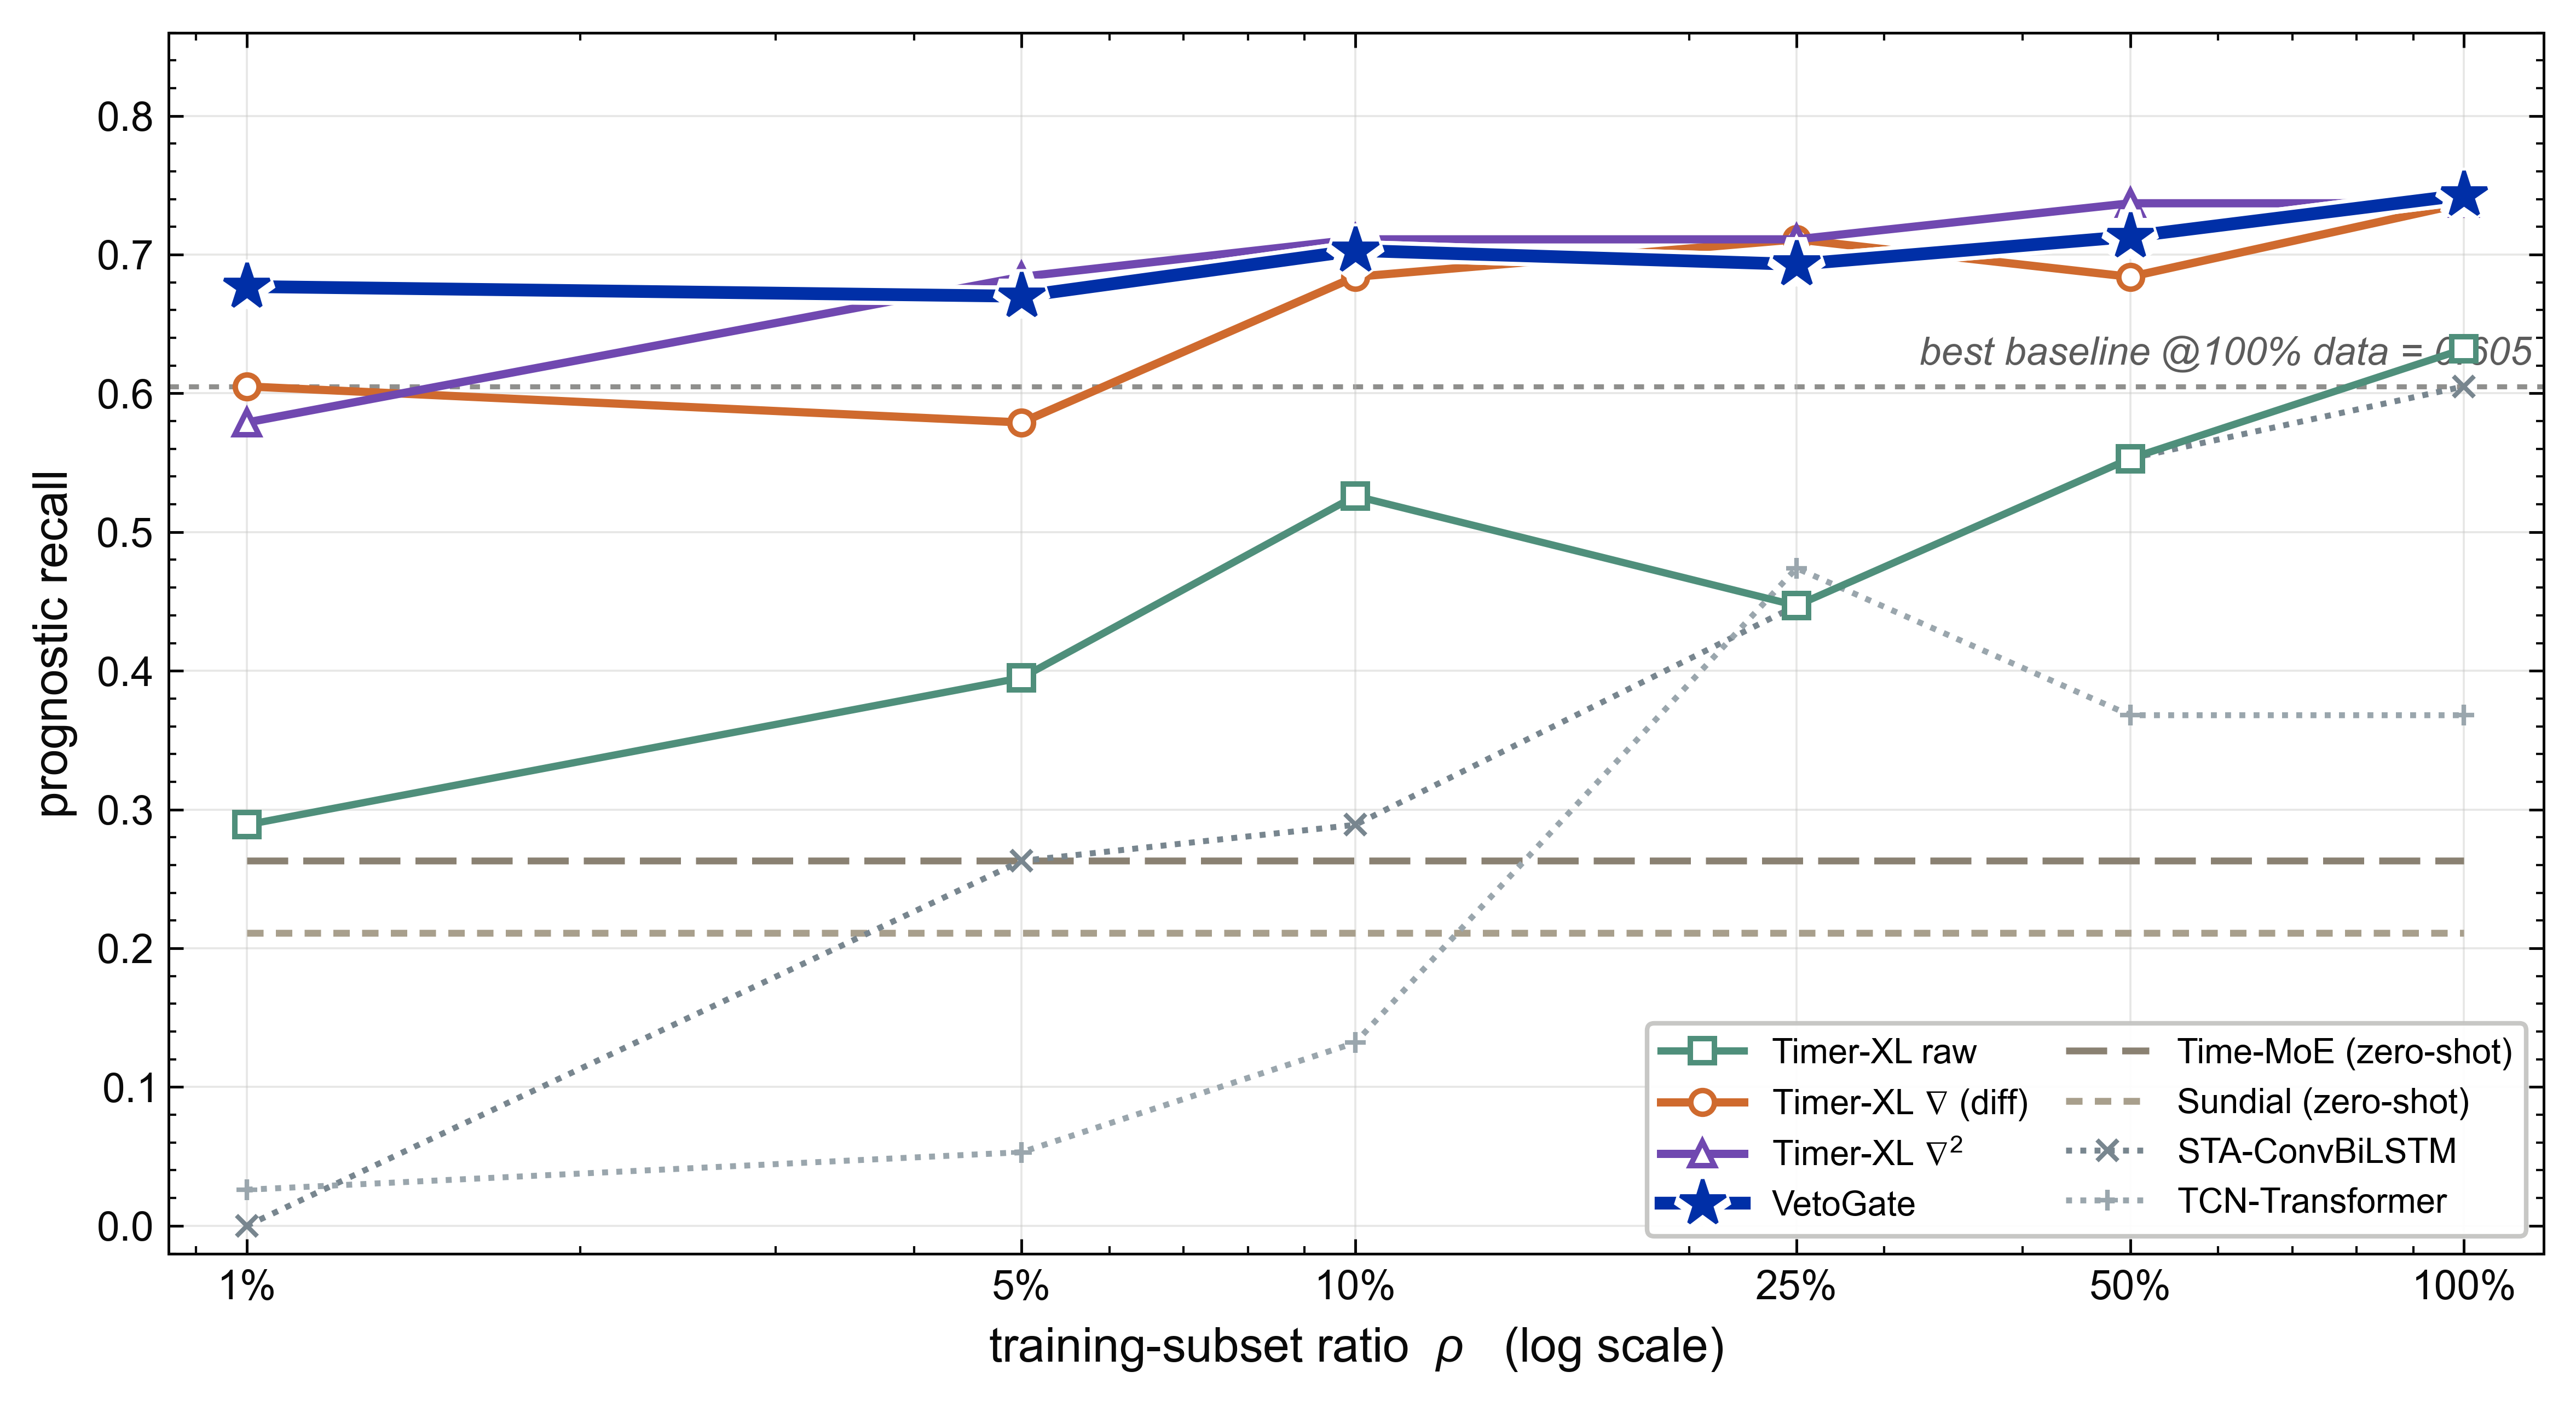

In [24]:
# === Fig. 4 — prognostic recall vs rho ===
fig, ax = plt.subplots(figsize=(cm(FIG_W_CM), cm(11.0))); fig.patch.set_facecolor(PAPER)
_base_ax(ax)
# best-baseline @100% reference (headline: operators @1% already beat it)
best_base_100 = max(RECALL["sta"][-1], RECALL["tcn"][-1])   # 0.535 (STA)
ax.axhline(best_base_100, color=GREY_MID, ls=(0,(2,2)), lw=1.1, zorder=1)
# label sits at the right end of the line: on the left the raw curve sweeps through it
ax.text(115, best_base_100+0.010, f"best baseline @100% data = {best_base_100:.3f}",
        fontsize=FS["note"], color=GREY_DARK, va="bottom", ha="right", style="italic")
for k in FIG4SET:
    _plot_curve(ax, k, RECALL)
_finish_x(ax)
ax.set_ylabel("prognostic recall", fontsize=FS["label"], color=INK)
ax.set_ylim(-0.02, 0.86)
ax.legend(fontsize=FS["legend"], ncol=2, loc="lower right", frameon=True, framealpha=0.95, facecolor=PAPER,
          edgecolor=GREY_LIGHT, columnspacing=1.1, handlelength=2.4)
fig.tight_layout(); _save(fig, "fig4_recall_vs_rho"); plt.show()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/fig5_far_lead_vs_rho.png + .svg/.pdf/.tiff


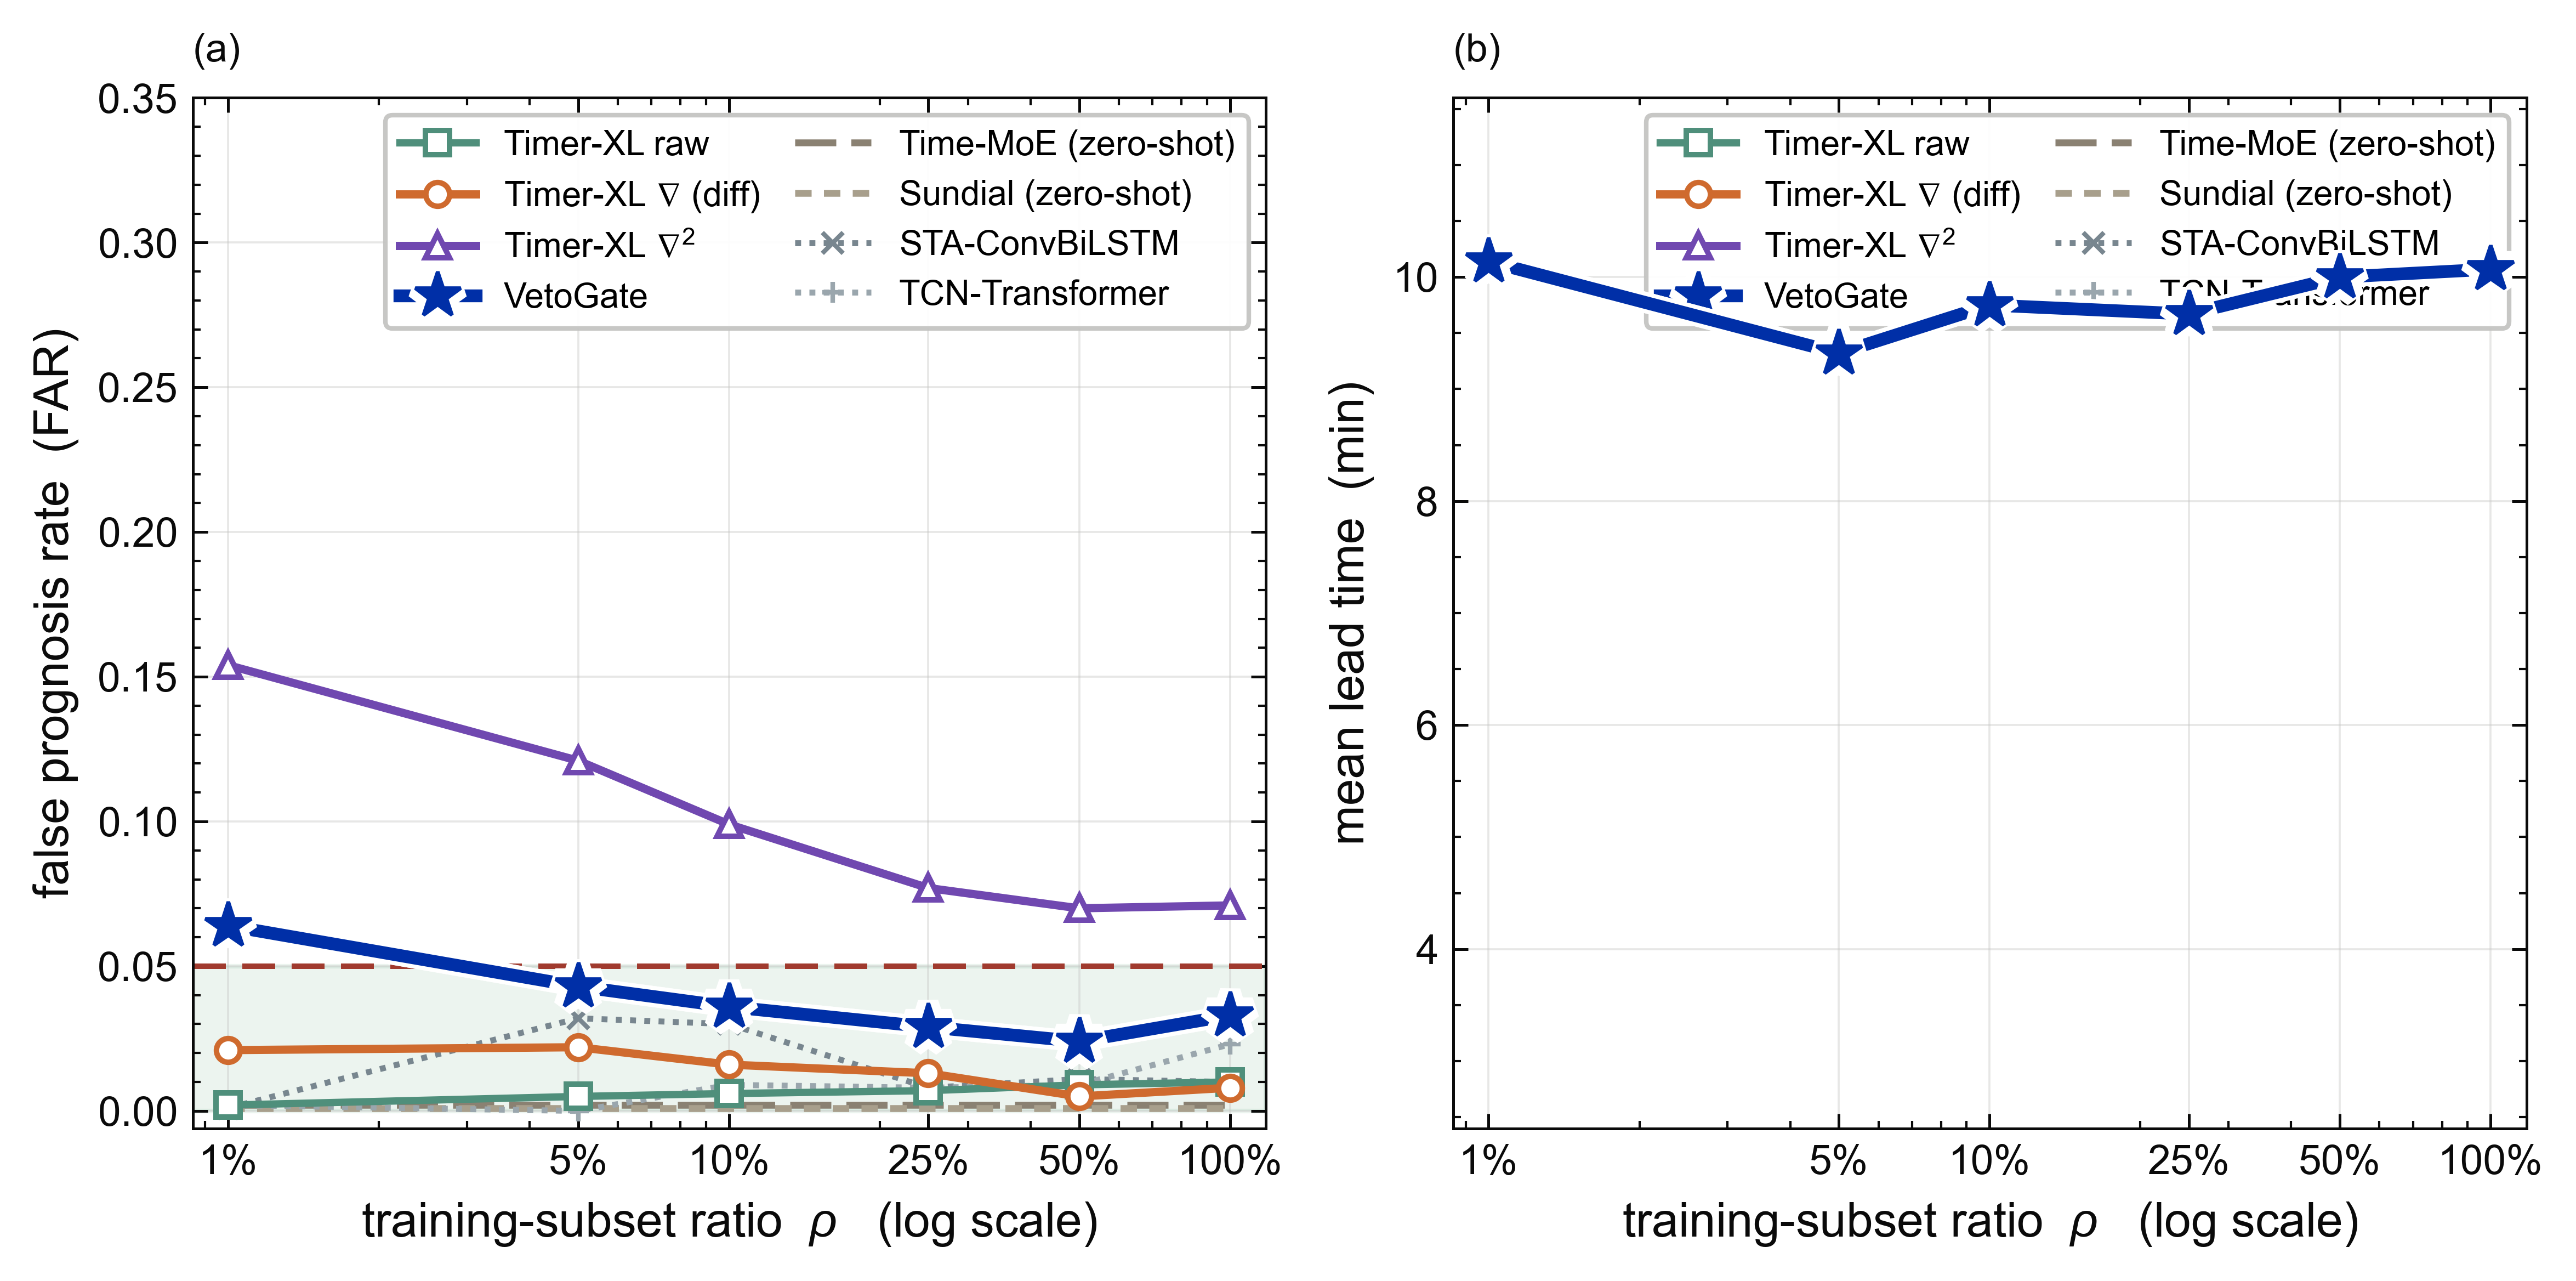

In [25]:
# === Fig. 5 — (a) FAR  (b) lead time vs rho ===
fig, (axa, axb) = plt.subplots(1, 2, figsize=(cm(FIG_W_CM), cm(10.0))); fig.patch.set_facecolor(PAPER)
for ax in (axa, axb): _base_ax(ax)

# (a) FAR  — shade FAR<=0.05 budget
axa.axhspan(0, 0.05, color="#2e8b57", alpha=0.09, zorder=0)
axa.axhline(0.05, color="#a03a2e", lw=1.2, ls=(0,(6,3)), zorder=2)
# axa.text(1.02, 0.052, "FAR = 0.05 budget", fontsize=FS["note"], color="#a03a2e", va="bottom", ha="left")
for k in FIG4SET: _plot_curve(axa, k, FAR)
_finish_x(axa)
axa.set_ylabel("false prognosis rate  (FAR)", fontsize=FS["label"], color=INK)
axa.set_ylim(-0.006, 0.3500)
axa.set_title("(a)", fontsize=FS["title"], color=INK, loc="left", pad=8)
axa.legend(fontsize=FS["legend"], ncol=2, loc="upper right", frameon=True, framealpha=0.95, facecolor=PAPER,
           edgecolor=GREY_LIGHT, columnspacing=1.0, handlelength=2.2)

# (b) lead time
for k in FIG4SET: _plot_curve(axb, k, LEAD)
_finish_x(axb)
axb.set_ylabel("mean lead time  (min)", fontsize=FS["label"], color=INK)
axb.set_ylim(2.4, 11.6)
axb.set_title("(b)", fontsize=FS["title"], color=INK, loc="left", pad=8)
axb.legend(fontsize=FS["legend"], ncol=2, loc="upper right", frameon=True, framealpha=0.95, facecolor=PAPER,
           edgecolor=GREY_LIGHT, columnspacing=1.0, handlelength=2.2)
fig.tight_layout(); _save(fig, "fig5_far_lead_vs_rho"); plt.show()


saved: /home/aicode/sherwin/TSFM/figures/IDV13_XMEAS10/figxx_pr_lead_vs_rho.png + .svg/.pdf/.tiff


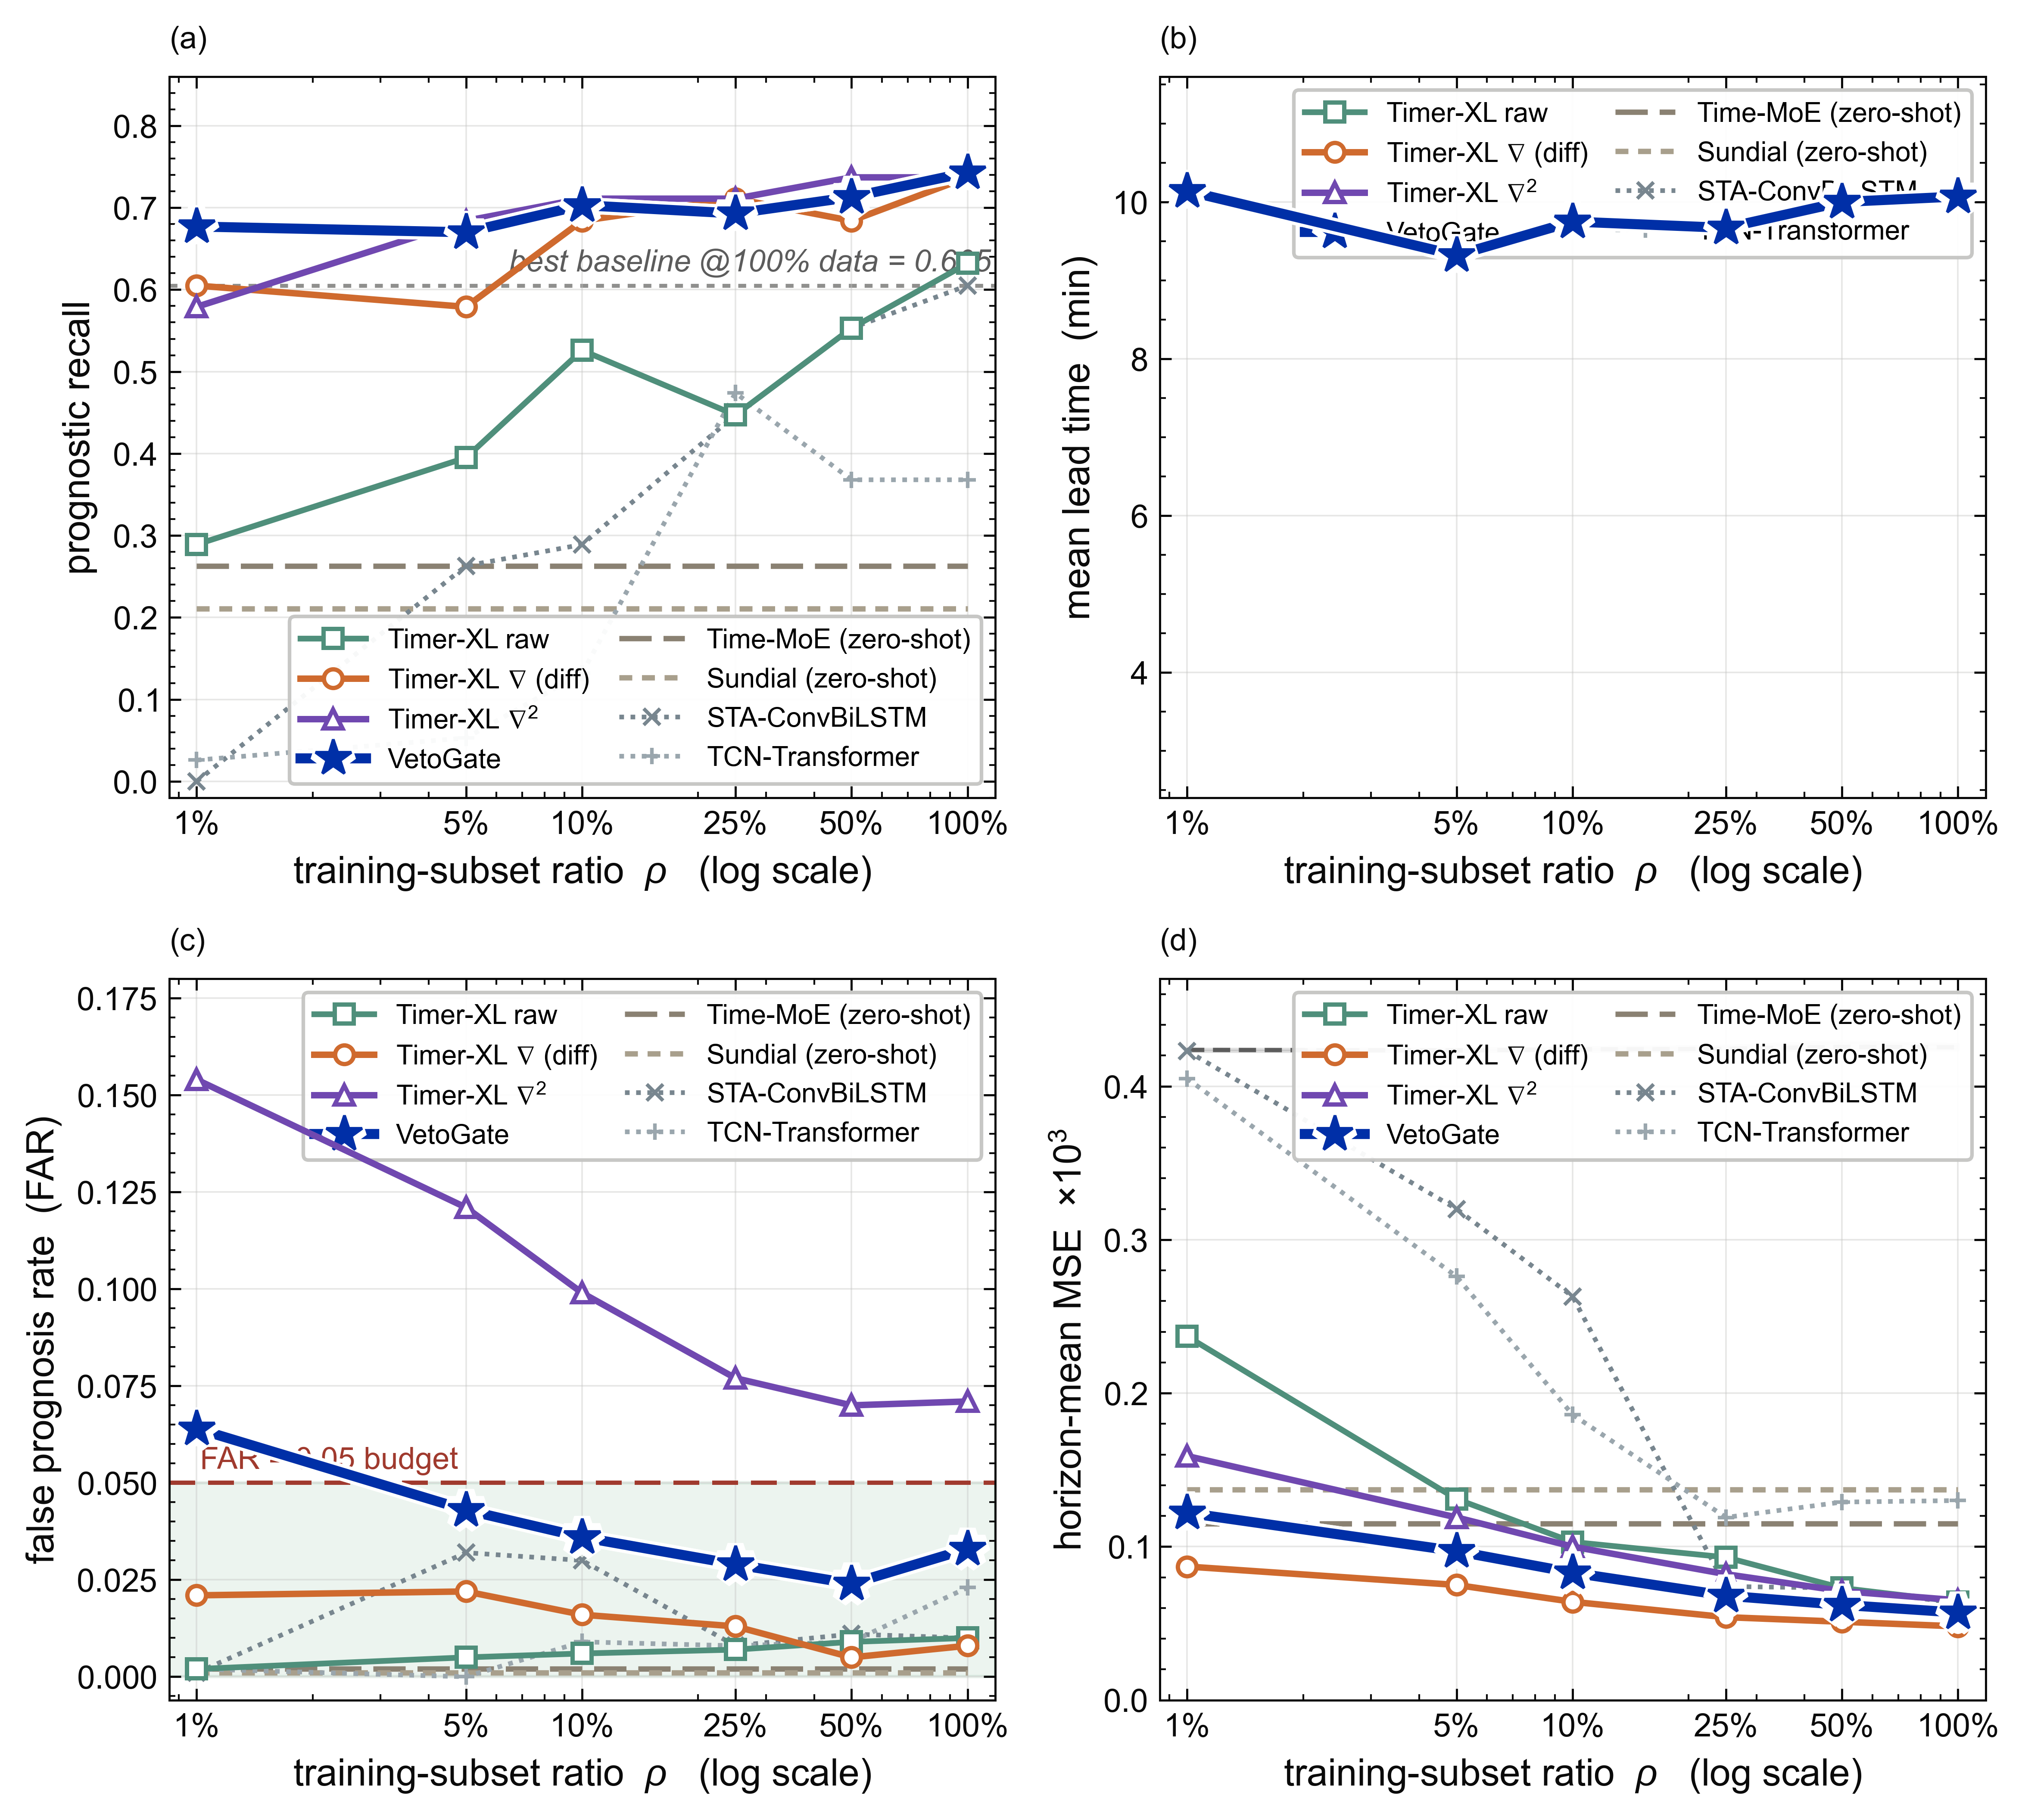

In [1]:
# === Fig. x — four quantitative comparisons in a 2x2 layout (VetoGate) ===
fig, axes = plt.subplots(2, 2, figsize=(cm(FIG_W_CM), cm(18))); fig.patch.set_facecolor(PAPER)
axa, axb, axc, axd = axes.ravel()
for ax in (axa, axb, axc, axd): _base_ax(ax)

# (a) PR best-baseline @100% reference (headline: operators @1% already beat it)
best_base_100 = max(RECALL["sta"][-1], RECALL["tcn"][-1])   # 0.535 (STA)
axa.axhline(best_base_100, color=GREY_MID, ls=(0,(2,2)), lw=1.1, zorder=1)
# label sits at the right end of the line: on the left the raw curve sweeps through it
axa.text(115, best_base_100+0.010, f"best baseline @100% data = {best_base_100:.3f}",
        fontsize=FS["note"], color=GREY_DARK, va="bottom", ha="right", style="italic")
for k in FIG4SET:
    _plot_curve(axa, k, RECALL)
_finish_x(axa)
axa.set_ylabel("prognostic recall", fontsize=FS["label"], color=INK)
axa.set_ylim(-0.02, 0.86)
axa.set_title("(a)", fontsize=FS["title"], color=INK, loc="left", pad=8)
axa.legend(fontsize=FS["legend"], ncol=2, loc="lower right", frameon=True, framealpha=0.95, facecolor=PAPER,
          edgecolor=GREY_LIGHT, columnspacing=1.1, handlelength=2.4)

# (b) lead time
for k in FIG4SET: _plot_curve(axb, k, LEAD)
_finish_x(axb)
axb.set_ylabel("mean lead time  (min)", fontsize=FS["label"], color=INK)
# Paper lead-time definition has a 3-min minimum (forecast-origin warning).
axb.set_ylim(2.4, 11.6)
axb.set_title("(b)", fontsize=FS["title"], color=INK, loc="left", pad=8)
axb.legend(fontsize=FS["legend"], ncol=2, loc="upper right", frameon=True, framealpha=0.95, facecolor=PAPER,
           edgecolor=GREY_LIGHT, columnspacing=1.0, handlelength=2.2)

# (c) FAR  — shade FAR<=0.05 budget
axc.axhspan(0, 0.05, color="#2e8b57", alpha=0.09, zorder=0)
axc.axhline(0.05, color="#a03a2e", lw=1.2, ls=(0,(6,3)), zorder=2)
axc.text(1.02, 0.052, "FAR = 0.05 budget", fontsize=FS["note"], color="#a03a2e", va="bottom", ha="left")
for k in FIG4SET: _plot_curve(axc, k, FAR)
_finish_x(axc)
axc.set_ylabel("false prognosis rate  (FAR)", fontsize=FS["label"], color=INK)
axc.set_ylim(-0.006, 0.18)
axc.set_title("(c)", fontsize=FS["title"], color=INK, loc="left", pad=8)
axc.legend(fontsize=FS["legend"], ncol=2, loc="upper right", frameon=True, framealpha=0.95, facecolor=PAPER,
           edgecolor=GREY_LIGHT, columnspacing=1.0, handlelength=2.2)

# (d) horizon-mean MSE x10^3, including the collapsed DL baseline band
allc = np.array(list(MSE_COLLAPSED.values()))
lo, hi = allc.min(0), allc.max(0)
axd.fill_between(RHO_PCT, lo, hi, color=GREY_MID, alpha=0.28, zorder=1)
axd.plot(RHO_PCT, allc.mean(0), color=GREY_DARK, lw=1.2, ls=(0,(4,2)), zorder=2)
# axd.text(2.4, 0.35, "collapsed DL baselines \n (DiPCA-LSTM, CNN-LSTM, LSTM-GRU)",
#          fontsize=FS["note"], color=GREY_DARK, va="bottom", ha="left", style="italic")
for k in FIG4SET: _plot_curve(axd, k, MSE)
_finish_x(axd)
axd.set_ylabel(r"horizon-mean MSE  $\times 10^{3}$", fontsize=FS["label"], color=INK)
axd.set_ylim(0.0, 0.47)
axd.set_title("(d)", fontsize=FS["title"], color=INK, loc="left", pad=8)
axd.legend(fontsize=FS["legend"], ncol=2, loc="upper right", frameon=True, framealpha=0.95, facecolor=PAPER,
           edgecolor=GREY_LIGHT, columnspacing=1.0, handlelength=2.2)

fig.tight_layout();
_save(fig, "figxx_pr_lead_vs_rho"); 
plt.show()


In [26]:
# # === Fig. 6 — recall vs FAR, one marker per (operator, rho) + Pareto front ===
# fig, ax = plt.subplots(figsize=(cm(FIG_W_CM), cm(13.0))); fig.patch.set_facecolor(PAPER)
# _base_ax(ax)
# # FAR=0.05 budget
# ax.axvspan(0, 0.05, color="#2e8b57", alpha=0.08, zorder=0)
# ax.axvline(0.05, color="#a03a2e", lw=1.2, ls=(0,(6,3)), zorder=2)
# ax.text(0.048, 0.44, "FAR = 0.05 budget", color="#a03a2e", fontsize=FS["note"],
#         rotation=90, va="bottom", ha="right")

# pts = []   # (far, recall, op, rho_idx)
# sizes = np.linspace(38, 180, len(RHO_PCT))     # small rho -> small marker
# for op in OPS:
#     c, mk, ls, lw, lab = STYLE[op]
#     hero = op == "union"
#     ms = 2.0 if hero else 1.0      # '*' 的视觉面积比方/圆/三角小，且 Union 要突出
#     fx = FAR[op]; ry = RECALL[op]
#     # faint trajectory across rho
#     ax.plot(fx, ry, color=c, lw=2.0 if hero else 1.0, alpha=0.55 if hero else 0.30,
#             zorder=4 if hero else 3)
#     for i in range(len(RHO_PCT)):
#         ax.scatter(fx[i], ry[i], s=sizes[i]*ms, marker=mk, c=c,
#                    alpha=(0.55+0.45*i/5) if hero else (0.30+0.55*i/5),
#                    edgecolor="white", linewidth=1.0 if hero else 0.8,
#                    zorder=7 if hero else 6)
#         pts.append((fx[i], ry[i], op, i))
#     ax.scatter([], [], s=170 if hero else 90, marker=mk, c=c,
#                edgecolor="white", label=lab)  # legend proxy

# # empirical Pareto front (max recall, min FAR)
# P = sorted(pts, key=lambda p: (p[0], -p[1]))
# front, best = [], -1
# for far, rec, op, i in P:
#     if rec > best:
#         front.append((far, rec)); best = rec
# fx = [p[0] for p in front]; fy = [p[1] for p in front]
# # step line (up-left frontier)
# sx, sy = [], []
# for j in range(len(front)):
#     sx.append(fx[j]); sy.append(fy[j])
#     if j+1 < len(front): sx.append(fx[j+1]); sy.append(fy[j])
# ax.plot(sx, sy, color=INK, lw=1.6, ls="-", zorder=5, alpha=0.75)
# ax.scatter(fx, fy, s=52, facecolor="none", edgecolor=INK, linewidth=1.4, zorder=8)
# ax.text(0.084, 0.735, "Pareto front", fontsize=FS["note"], color=INK, style="italic",
#         rotation=0, va="bottom", ha="left")

# # rho size legend
# for i in (0, 5):
#     ax.scatter([], [], s=sizes[i], marker="o", c=GREY_MID, edgecolor="white",
#                label=f"$\\rho$ = {RHO_LAB[i]}")
# ax.set_xlabel(r"false prognosis rate  FAR   (lower is better $\leftarrow$)",
#               fontsize=FS["label"], color=INK)
# ax.set_ylabel(r"recall   (higher is better $\uparrow$)", fontsize=FS["label"], color=INK)
# ax.set_xlim(-0.006, 0.175); ax.set_ylim(0.40, 0.83)
# ax.legend(fontsize=FS["legend"], loc="lower right", frameon=True, framealpha=0.95, facecolor=PAPER, edgecolor=GREY_LIGHT,
#           ncol=2, columnspacing=1.0)
# fig.tight_layout(); _save(fig, "fig6_recall_far_pareto"); plt.show()


In [27]:
# # === Fig. 7 — horizon-mean MSE x10^3 vs rho ===
# fig, ax = plt.subplots(figsize=(cm(FIG_W_CM), cm(11.0))); fig.patch.set_facecolor(PAPER)
# _base_ax(ax)
# # collapsed DL baselines -> grey band near 0.42
# allc = np.array(list(MSE_COLLAPSED.values()))
# lo, hi = allc.min(0), allc.max(0)
# ax.fill_between(RHO_PCT, lo, hi, color=GREY_MID, alpha=0.28, zorder=1)
# ax.plot(RHO_PCT, allc.mean(0), color=GREY_DARK, lw=1.2, ls=(0,(4,2)), zorder=2)
# ax.text(2.0, 0.44, "collapsed DL baselines\n(DiPCA-LSTM, CNN-LSTM, LSTM-GRU)",
#         fontsize=FS["note"], color=GREY_DARK, va="bottom", ha="left", style="italic")
# for k in FIG4SET: _plot_curve(ax, k, MSE)
# _finish_x(ax)
# ax.set_ylabel(r"horizon-mean MSE  $\times 10^{3}$", fontsize=FS["label"], color=INK)
# ax.set_ylim(0.0, 0.47)
# ax.legend(fontsize=FS["legend"], ncol=2, loc="center right", frameon=True, framealpha=0.95, facecolor=PAPER,
#           edgecolor=GREY_LIGHT, columnspacing=1.1, handlelength=2.4)
# fig.tight_layout(); _save(fig, "fig7_mse_vs_rho"); plt.show()
